# Análisis de Checklists - Adaptación de Textos

Este notebook realiza un análisis comparativo de los checklists de cumplimiento para diferentes herramientas de adaptación de textos, basándose en los datos del archivo `comparacion.xlsx`.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from decimal import Decimal

# Configuración de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Data Loading

We load the main sheet to retrieve tool names and then iterate over the numbered sheets (1-N) to extract detailed checklists.

In [14]:
file_path = 'comparacion.xlsx'

# Leer la matriz comparativa para obtener los nombres de las herramientas
df_matriz = pd.read_excel(file_path, sheet_name='Matriz comparativa')

# Las herramientas están en las columnas a partir de la cuarta (índice 3)
tool_names = df_matriz.columns[3:].tolist()
tool_names = [t for t in tool_names if 'AdaptaTuTexto' not in t]
print(f"Tools found: {len(tool_names)}")
print(tool_names)

Tools found: 12
['Lectura Fácil [Referencia]', 'FACILE', 'Placea', 'Asistente de lectura fácil “Antonio Gonzales Crespo”', 'Asistente de lectura fácil “Mark Jonathan Camacho Escatel”: ', 'Gemini 3.1 Pro', 'GPT 5.4 Think', 'Claude Sonnet 4.6', 'deepseek-v3.2', 'SimpleText (ClearText)', 'Modelo_Qwen3.5_9B', 'Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"']


In [15]:
# Diccionario para almacenar los checklists de cada herramienta
checklists = {}

for i, tool in enumerate(tool_names):
    sheet_name = str(i + 1)
    try:
        # Leer la hoja numerada correspondiente
        df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Limpiar datos: nos interesan las filas que tienen un ítem de verificación
        # (normalmente hasta la fila 18-19, antes del total)
        df_clean = df_sheet.dropna(subset=['Ítem de Validación'])
        df_clean = df_clean[df_clean['Ítem de Validación'] != 'Total Cumplidos']
        
        # Guardar en el diccionario
        checklists[tool] = df_clean
    except Exception as e:
        print(f"Error cargando la hoja {sheet_name} para la herramienta {tool}: {e}")

print("Checklists loaded successfully.")


Checklists loaded successfully.


## 2. Data Consolidation

We create a master DataFrame where each row is a checklist item and each column is a tool.

In [16]:
# Obtener la lista base de ítems (usando la primera herramienta como referencia)
base_items = checklists[tool_names[0]][['Categoría', 'Ítem de Validación']].copy()
base_items['Categoría'] = base_items['Categoría'].ffill() # Rellenar categorías vacías

# Crear el DataFrame maestro
df_master = base_items.copy()

for tool in tool_names:
    if tool in checklists:
        # Extraer la columna de cumplimiento
        # 1.0 = SÍ, 0.5 = PARCIAL, 0.0 = NO
        compliance = checklists[tool]['Cumple'].values
        
        # Asegurar que la longitud coincida (por si acaso)
        if len(compliance) == len(df_master):
            df_master[tool] = pd.to_numeric(pd.Series(compliance), errors='coerce').fillna(0).values
        else:
            # Si hay diferencia, mapeamos por nombre de ítem para seguridad
            tool_data = checklists[tool].set_index('Ítem de Validación')['Cumple']
            df_master[tool] = df_master['Ítem de Validación'].map(tool_data)
            df_master[tool] = pd.to_numeric(df_master[tool], errors='coerce').fillna(0)

df_master.head()

,Categoría,Ítem de Validación,Lectura Fácil [Referencia],FACILE,Placea,Asistente de lectura fácil “Antonio Gonzales Crespo”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText),Modelo_Qwen3.5_9B,"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez"""
0,Identificación,"Nombre, DNI/pasaporte y mail",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
1,Estructura,Dos capas diferenciadas,1.0,1.0,1.0,1.0,1.0,0.0,0.5,0.0,0.0,1.0,1.0,1.0
2,Básica (Capa 1),Identificación clara,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Básica (Capa 1),Identidad,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,Básica (Capa 1),Fines del tratamiento,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. Compliance Analysis

### Total Score by Tool

C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_20780\4045529781.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_totals, x='Items Fulfilled', y='Tool', palette='viridis')


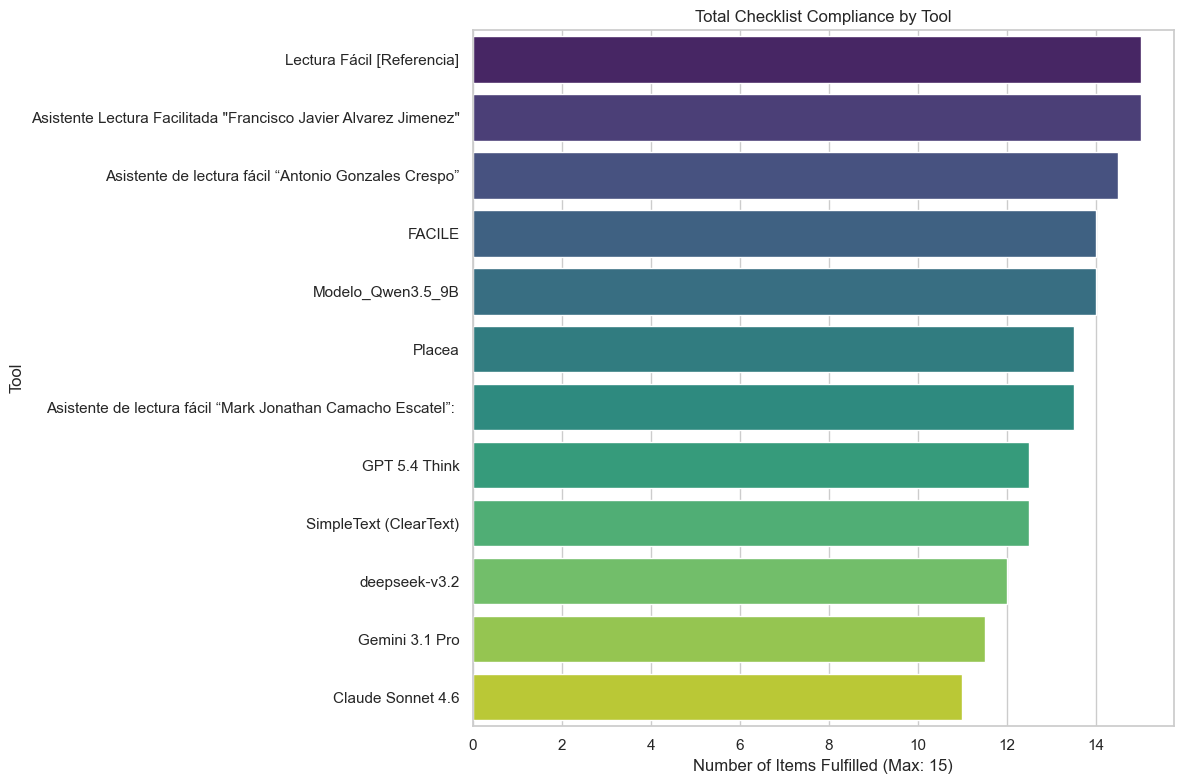

In [17]:
totals = df_master[tool_names].sum().sort_values(ascending=False)
df_totals = pd.DataFrame({'Tool': totals.index, 'Items Fulfilled': totals.values})
df_totals['Compliance (%)'] = (df_totals['Items Fulfilled'] / len(df_master)) * 100

NUM_ITEMS_CHECKLIST = len(df_master)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_totals, x='Items Fulfilled', y='Tool', palette='viridis')
plt.title('Total Checklist Compliance by Tool')
plt.xlabel(f'Number of Items Fulfilled (Max: {NUM_ITEMS_CHECKLIST})')
plt.ylabel('Tool')
plt.tight_layout()
plt.show()

In [18]:
df_totals_checker = totals.to_frame(name='Items Fulfilled')
df_totals_checker["Compliance"] = df_totals_checker['Items Fulfilled'].apply(lambda x: np.round((x/NUM_ITEMS_CHECKLIST)*100,3))
df_totals_checker.set_index(df_totals_checker.index, inplace=True)
df_totals_checker.to_excel("totales_checkers.xlsx", index=True)
display(df_totals_checker)


,Items Fulfilled,Compliance
Lectura Fácil [Referencia],15.0,100.000
"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez""",15.0,100.000
Asistente de lectura fácil “Antonio Gonzales Crespo”,14.5,96.667
FACILE,14.0,93.333
Modelo_Qwen3.5_9B,14.0,93.333
Placea,13.5,90.000
Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,13.5,90.000
GPT 5.4 Think,12.5,83.333
SimpleText (ClearText),12.5,83.333
deepseek-v3.2,12.0,80.000


### Detailed Compliance Heatmap

This map shows exactly which points each tool fails.

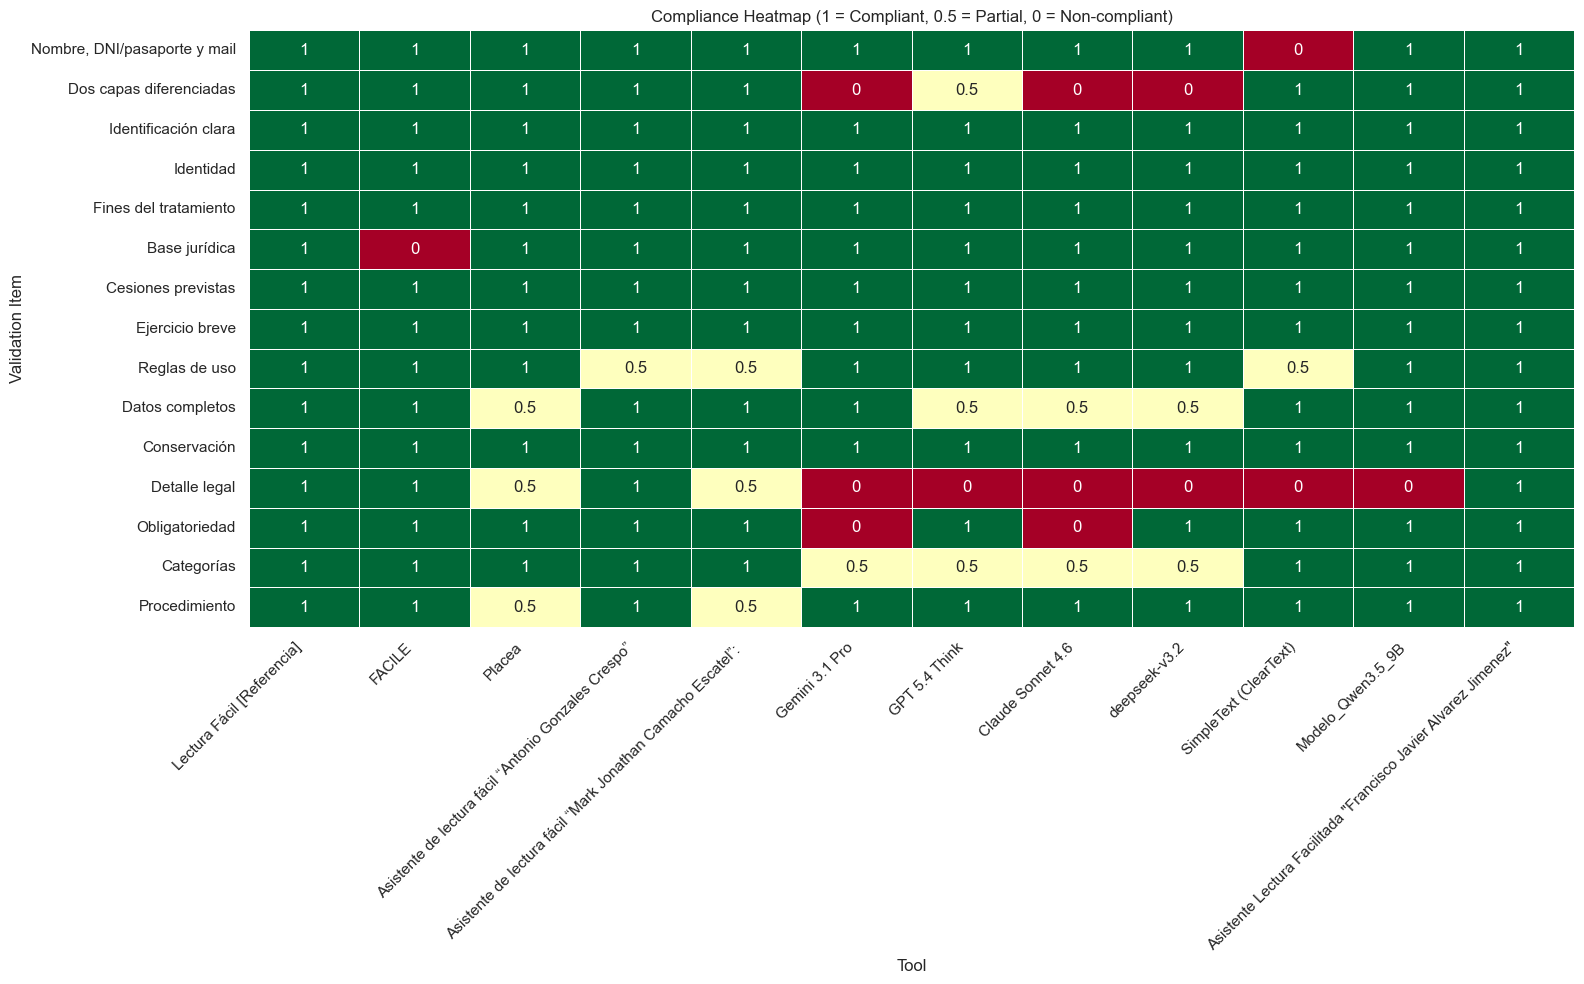

In [19]:
plt.figure(figsize=(16, 10))
heatmap_data = df_master.set_index('Ítem de Validación')[tool_names]
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', cbar=False, linewidths=.5)
plt.title('Compliance Heatmap (1 = Compliant, 0.5 = Partial, 0 = Non-compliant)')
plt.ylabel('Validation Item')
plt.xlabel('Tool')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Most Non-Compliant Items

In [20]:
columns = ["Categoría", "Ítem de Validación",	"Lectura Fácil [Referencia]"]

df_master["Total Non-Compliance"] = df_master.apply(
                                    lambda x: x.drop(columns).count() - x.drop(columns).sum()
                                    , axis=1
                                    )
df_master[["Categoría", "Ítem de Validación", "Total Non-Compliance"]].sort_values(by="Total Non-Compliance", ascending = False)

,Categoría,Ítem de Validación,Total Non-Compliance
11,Adicional (Capa 2),Detalle legal,7.0
1,Estructura,Dos capas diferenciadas,3.5
9,Adicional (Capa 2),Datos completos,2.0
13,Adicional (Capa 2),Categorías,2.0
12,Adicional (Capa 2),Obligatoriedad,2.0
8,Garantías,Reglas de uso,1.5
0,Identificación,"Nombre, DNI/pasaporte y mail",1.0
5,Básica (Capa 1),Base jurídica,1.0
14,Adicional (Capa 2),Procedimiento,1.0
3,Básica (Capa 1),Identidad,0.0


### Analysis by Category

We group results to see which legal or content sections are most neglected.

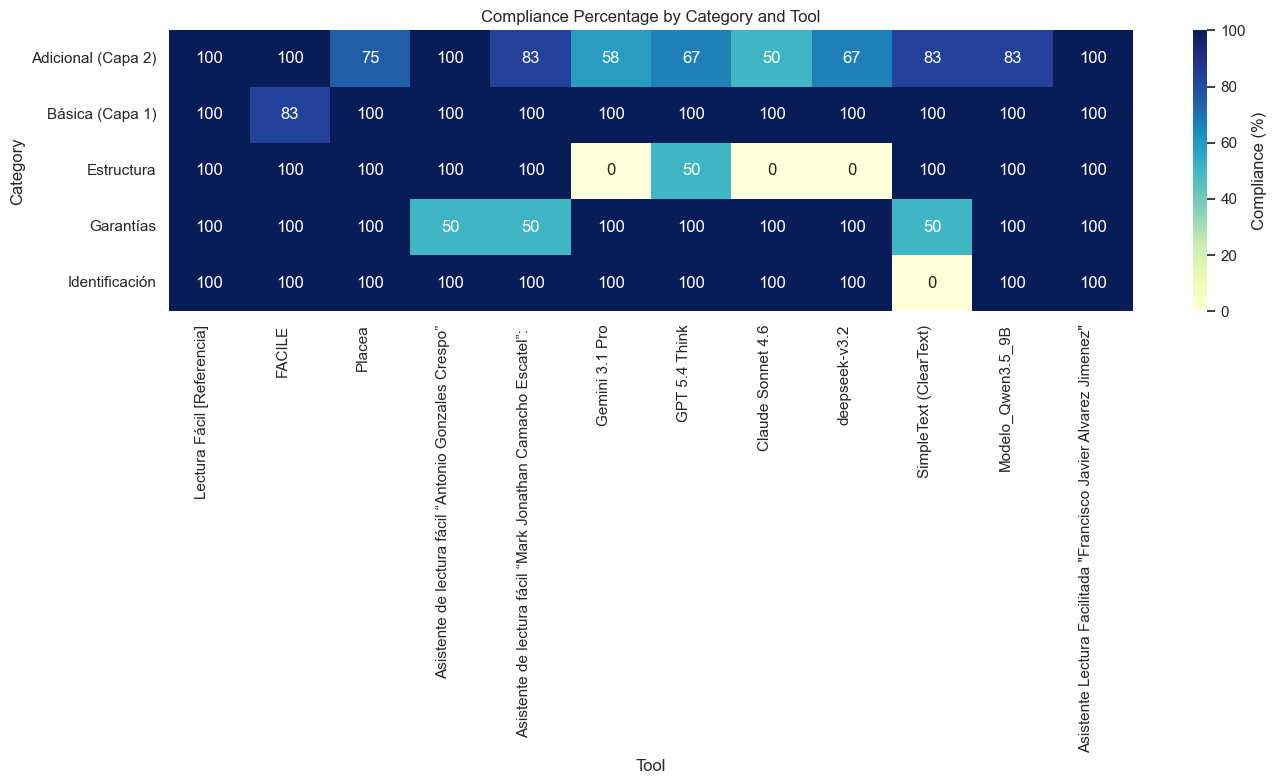

In [21]:
df_cat = df_master.groupby('Categoría')[tool_names].mean() * 100

plt.figure(figsize=(14, 8))
sns.heatmap(df_cat, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Compliance (%)'})
plt.title('Compliance Percentage by Category and Tool')
plt.ylabel('Category')
plt.xlabel('Tool')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

## 4. Detailed Summary Tables

The following tables show full compliance, partial compliance, and non-compliance for each tool and item.

In [22]:
# Calcular totales por tipo de cumplimiento
summary_list = []
for tool in tool_names:
    counts = df_master[tool].value_counts()
    summary_list.append({
        'Tool': tool,
        'Compliant (1)': int(counts.get(1.0, 0)),
        'Partial (0.5)': int(counts.get(0.5, 0)),
        'Non-compliant (0)': int(counts.get(0.0, 0))
    })

df_resumen = pd.DataFrame(summary_list)
df_resumen

,Tool,Compliant (1),Partial (0.5),Non-compliant (0)
0,Lectura Fácil [Referencia],15,0,0
1,FACILE,14,0,1
2,Placea,12,3,0
3,Asistente de lectura fácil “Antonio Gonzales C...,14,1,0
4,Asistente de lectura fácil “Mark Jonathan Cama...,12,3,0
5,Gemini 3.1 Pro,11,1,3
6,GPT 5.4 Think,11,3,1
7,Claude Sonnet 4.6,10,2,3
8,deepseek-v3.2,11,2,2
9,SimpleText (ClearText),12,1,2


In [23]:
# Función para dar formato visual
def format_compliance(val):
    if val == 1.0: return 'YES'
    if val == 0.5: return 'PARTIAL'
    return 'NO'

df_visual = df_master.copy()
for tool in tool_names:
    df_visual[tool] = df_visual[tool].apply(format_compliance)

df_visual

,Categoría,Ítem de Validación,Lectura Fácil [Referencia],FACILE,Placea,Asistente de lectura fácil “Antonio Gonzales Crespo”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText),Modelo_Qwen3.5_9B,"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez""",Total Non-Compliance
0,Identificación,"Nombre, DNI/pasaporte y mail",YES,YES,YES,YES,YES,YES,YES,YES,YES,NO,YES,YES,1.0
1,Estructura,Dos capas diferenciadas,YES,YES,YES,YES,YES,NO,PARTIAL,NO,NO,YES,YES,YES,3.5
2,Básica (Capa 1),Identificación clara,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0
3,Básica (Capa 1),Identidad,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0
4,Básica (Capa 1),Fines del tratamiento,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0
5,Básica (Capa 1),Base jurídica,YES,NO,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,1.0
6,Básica (Capa 1),Cesiones previstas,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0
7,Básica (Capa 1),Ejercicio breve,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0
8,Garantías,Reglas de uso,YES,YES,YES,PARTIAL,PARTIAL,YES,YES,YES,YES,PARTIAL,YES,YES,1.5
9,Adicional (Capa 2),Datos completos,YES,YES,PARTIAL,YES,YES,YES,PARTIAL,PARTIAL,PARTIAL,YES,YES,YES,2.0


## Table 5.2 — Legal Information Completeness by Tool (Paper Export)

In [24]:
# Tool-to-group mapping for paper table
TOOL_GROUPS = {
    'Placea': 'G1',
    'Asistente de lectura fácil "Antonio Gonzales Crespo"': 'G1',
    'Asistente de lectura fácil "Mark Jonathan Camacho Escatel": ': 'G1',
    'Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"': 'G1',
    'Gemini 3.1 Pro': 'G2',
    'GPT 5.4 Think': 'G2',
    'Claude Sonnet 4.6': 'G2',
    'deepseek-v3.2': 'G2',
    'FACILE': 'G3',
    'SimpleText (ClearText)': 'G3',
    'Modelo_Qwen3.5_9B': 'G3',
    'Lectura Fácil [Referencia]': 'Gold',
}

table_5_2 = df_totals_checker.copy().reset_index()
table_5_2.columns = ['Tool', 'Items Fulfilled', 'Compliance (%)']
table_5_2['Group'] = table_5_2['Tool'].map(TOOL_GROUPS)

# Sort: Gold first, then by compliance descending, excluding AdaptaTuTexto
mask_valid = table_5_2['Tool'].map(lambda t: t in TOOL_GROUPS)
table_5_2 = table_5_2[mask_valid].sort_values(
    ['Group', 'Compliance (%)'], ascending=[True, False]
).reset_index(drop=True)

# Reorder columns
table_5_2 = table_5_2[['Group', 'Tool', 'Items Fulfilled', 'Compliance (%)']]
display(table_5_2)

# Export
table_5_2.to_excel('table_5_2_checklist_compliance.xlsx', index=False)
print("Saved: table_5_2_checklist_compliance.xlsx")


,Group,Tool,Items Fulfilled,Compliance (%)
0,G1,"Asistente Lectura Facilitada ""Francisco Javier...",15.0,100.000
1,G1,Placea,13.5,90.000
2,G2,GPT 5.4 Think,12.5,83.333
3,G2,deepseek-v3.2,12.0,80.000
4,G2,Gemini 3.1 Pro,11.5,76.667
5,G2,Claude Sonnet 4.6,11.0,73.333
6,G3,FACILE,14.0,93.333
7,G3,Modelo_Qwen3.5_9B,14.0,93.333
8,G3,SimpleText (ClearText),12.5,83.333
9,Gold,Lectura Fácil [Referencia],15.0,100.000


Saved: table_5_2_checklist_compliance.xlsx
